#Kaggle

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "pitstops.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "eshummalik/pitstop-pulse-formula-1-performance-data",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipython-input-2963615565.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'pitstop-pulse-formula-1-performance-data' dataset.
First 5 records:    RaceId  DriverId  Stops  Year     Race  No        DriverName Code  \
0     258       100      1  1994  pacific  20        Erik Comas  COM   
1     258        79      1  1994  pacific   3     Ukyo Katayama  KAT   
2     258        57      1  1994  pacific   7     Mika Hakkinen  HAK   
3     258        71      1  1994  pacific   0        Damon Hill  HIL   
4     258       105      1  1994  pacific  24  Michele Alboreto  ALB   

                Car  Lap TimeOfDay    Time   Total  
0    Larrousse Ford    1  14:01:34  49.111  49.111  
1    Tyrrell Yamaha   17  14:20:46  28.482  28.482  
2   McLaren Peugeot   18  14:22:35  43.745  43.745  
3  Williams Renault   18  14:23:00  21.992  21.992  
4      Minardi Ford   19  14:24:39  27.693  27.693  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Better visuals
plt.style.use("seaborn-v0_8")
sns.set_context("talk")


In [ ]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

df.head()


Shape: (9921, 13)

Columns:
Index(['RaceId', 'DriverId', 'Stops', 'Year', 'Race', 'No', 'DriverName',
       'Code', 'Car', 'Lap', 'TimeOfDay', 'Time', 'Total'],
      dtype='object')

Data types:
RaceId         int64
DriverId       int64
Stops          int64
Year           int64
Race          object
No             int64
DriverName    object
Code          object
Car           object
Lap            int64
TimeOfDay     object
Time          object
Total         object
dtype: object

Missing values:
RaceId        0
DriverId      0
Stops         0
Year          0
Race          0
No            0
DriverName    0
Code          0
Car           1
Lap           0
TimeOfDay     0
Time          3
Total         0
dtype: int64


,RaceId,DriverId,Stops,Year,Race,No,DriverName,Code,Car,Lap,TimeOfDay,Time,Total
0,258,100,1,1994,pacific,20,Erik Comas,COM,Larrousse Ford,1,14:01:34,49.111,49.111
1,258,79,1,1994,pacific,3,Ukyo Katayama,KAT,Tyrrell Yamaha,17,14:20:46,28.482,28.482
2,258,57,1,1994,pacific,7,Mika Hakkinen,HAK,McLaren Peugeot,18,14:22:35,43.745,43.745
3,258,71,1,1994,pacific,0,Damon Hill,HIL,Williams Renault,18,14:23:00,21.992,21.992
4,258,105,1,1994,pacific,24,Michele Alboreto,ALB,Minardi Ford,19,14:24:39,27.693,27.693


In [ ]:
# Convert pit stop duration columns to numeric
df["Time"] = pd.to_numeric(df["Time"], errors="coerce")
df["Total"] = pd.to_numeric(df["Total"], errors="coerce")

# Drop rows with invalid pit stop times
df = df.dropna(subset=["Time", "Total"])


In [ ]:
driver_stops = (
    df.groupby("DriverName")["Stops"]
    .mean()
    .sort_values()
)

print("Drivers with least average pit stops:")
print(driver_stops.head(10))


Drivers with least average pit stops:
DriverName
Bertrand Gachot             1.0
Eric Bernard                1.0
Domenico Schiattarella      1.0
Gabriele Tarquini           1.0
Erik Comas                  1.0
David Brabham               1.0
Jean-Marc Gounon            1.0
Giovanni Lavaggi            1.0
Jean-Christophe Boullion    1.0
Yannick Dalmas              1.0
Name: Stops, dtype: float64


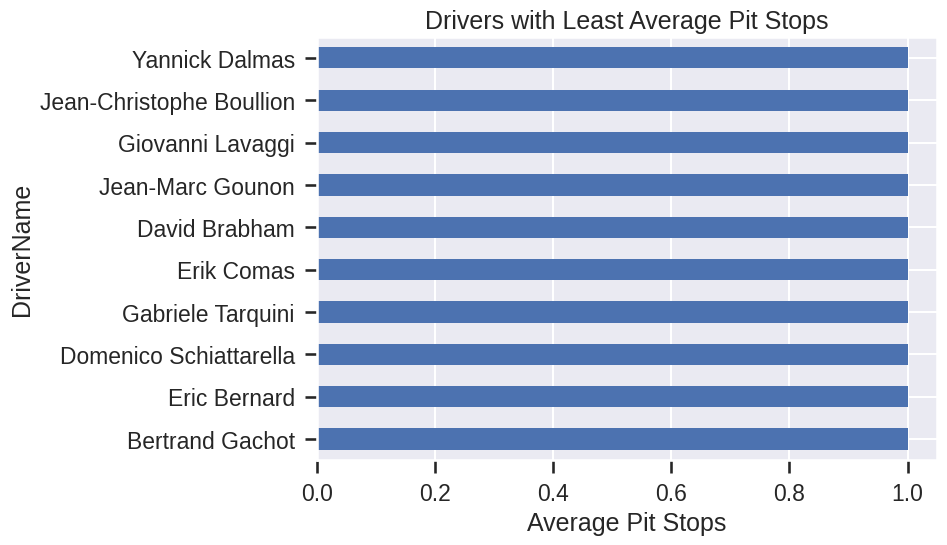

In [ ]:
driver_stops.head(10).plot(
    kind="barh",
    title="Drivers with Least Average Pit Stops",
    xlabel="Average Pit Stops"
)
plt.show()


In [ ]:
fastest_pitstops = df.sort_values("Time").head(10)

fastest_pitstops[[
    "Year", "Race", "DriverName", "Car", "Lap", "Time"
]]


,Year,Race,DriverName,Car,Lap,Time
9122,2009,europe,Luca Badoer,Ferrari,32,8.757
6820,2006,australia,Ralf Schumacher,Toyota,23,10.164
5597,2004,france,Nick Heidfeld,Jordan Ford,35,11.042
7164,2006,germany,Tiago Monteiro,MF1 Toyota,43,11.068
7158,2006,germany,Ralf Schumacher,Toyota,35,11.126
6412,2005,germany,Narain Karthikeyan,Jordan Toyota,44,11.193
2076,1998,australia,Mika Hakkinen,McLaren Mercedes,36,11.242
2532,1999,australia,Michael Schumacher,Ferrari,37,11.371
1646,1997,san-marino,Nicola Larini,Sauber Petronas,34,11.778
9654,2010,great-britain,Fernando Alonso,Ferrari,30,12.304


In [ ]:
df.loc[df["Time"].idxmin()]


,9122
RaceId,11
DriverId,69
Stops,2
Year,2009
Race,europe
No,3
DriverName,Luca Badoer
Code,BAD
Car,Ferrari
Lap,32


In [ ]:
team_efficiency = (
    df.groupby("Car")["Time"]
    .mean()
    .sort_values()
)

team_efficiency.head(10)


,Time
Car,
Sauber Ferrari,23.470515
Mercedes,24.345256
RBR Ferrari,24.475059
RBR Renault,24.496766
Williams Cosworth,24.824512
Brawn Mercedes,24.918492
Force India Mercedes,25.193307
Jordan Toyota,25.575803
RBR Cosworth,25.632167


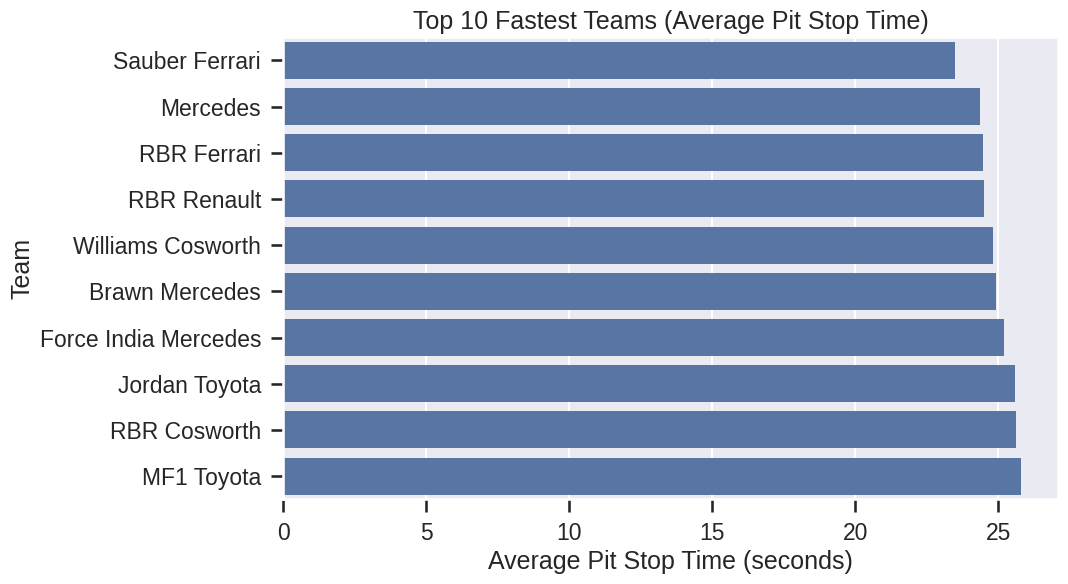

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=team_efficiency.head(10).values,
    y=team_efficiency.head(10).index
)
plt.title("Top 10 Fastest Teams (Average Pit Stop Time)")
plt.xlabel("Average Pit Stop Time (seconds)")
plt.ylabel("Team")
plt.show()


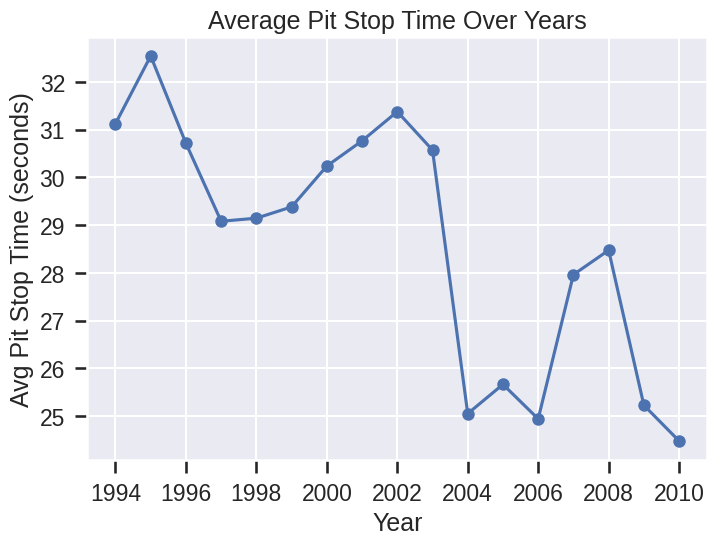

In [ ]:
yearly_trend = (
    df.groupby("Year")["Time"]
    .mean()
)

yearly_trend.plot(
    marker="o",
    title="Average Pit Stop Time Over Years",
    ylabel="Avg Pit Stop Time (seconds)"
)
plt.show()


In [ ]:
race_name = "pacific"

race_df = df[df["Race"] == race_name]

race_df.sort_values("Time").head(10)


,RaceId,DriverId,Stops,Year,Race,No,DriverName,Code,Car,Lap,TimeOfDay,Time,Total
23,258,71,2,1994,pacific,0,Damon Hill,HIL,Williams Renault,42,14:53:38,21.411,43.403
3,258,71,1,1994,pacific,0,Damon Hill,HIL,Williams Renault,18,14:23:00,21.992,21.992
25,258,105,2,1994,pacific,24,Michele Alboreto,ALB,Minardi Ford,42,14:54:52,22.694,50.387
33,258,77,2,1994,pacific,28,Gerhard Berger,BER,Ferrari,57,15:11:53,23.066,47.400
973,254,30,1,1995,pacific,1,Michael Schumacher,MSC,Benetton Renault,19,14:24:54,23.285,23.285
8,258,30,1,1994,pacific,5,Michael Schumacher,MSC,Benetton Ford,23,14:28:40,23.342,23.342
32,258,50,2,1994,pacific,6,Jos Verstappen,VER,Benetton Ford,54,15:09:39,23.846,48.535
28,258,30,2,1994,pacific,5,Michael Schumacher,MSC,Benetton Ford,51,15:04:18,24.181,47.523
14,258,77,1,1994,pacific,28,Gerhard Berger,BER,Ferrari,27,14:34:28,24.334,24.334
30,258,84,2,1994,pacific,8,Martin Brundle,BRU,McLaren Peugeot,53,15:07:00,24.524,55.094


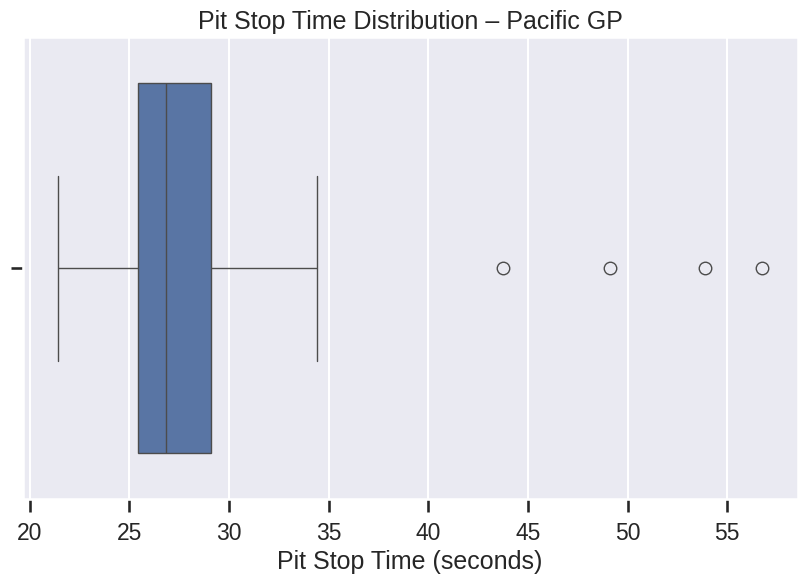

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=race_df, x="Time")
plt.title(f"Pit Stop Time Distribution – {race_name.title()} GP")
plt.xlabel("Pit Stop Time (seconds)")
plt.show()


# Hugging Face

In [ ]:
# Step 1: Install the necessary libraries

!pip install -q transformers gradio


# Step 2: Import libraries

from transformers import pipeline

import gradio as gr


# Step 3: Load the sentiment analysis pipeline

# This downloads a pre-trained model
# automatically

classifier = pipeline("sentiment-analysis")

# Step 4: Define a simple function for the app to use

def analyze_text(text):

    result = classifier(text)[0]

    return f"Label: {result['label']}, Score: {round(result['score'], 4)}"

# Step 5: Create the web interface

demo = gr.Interface(

    fn=analyze_text,

    inputs="text",

    outputs="text",

    title="My First AI Sentiment App",

    description="Type a sentence below to see if it's Positive or Negative!"

)

# Step 6: Launch the app

demo.launch(share=True)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://955b5287c347d8feb1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


#Fast AI

In [ ]:
# Block 1: Install fastai and duckduckgo_search (for image downloading)
!pip install -Uqq fastai duckduckgo_search

# Block 2: Import libraries and setup search function
from fastai.vision.all import *
from duckduckgo_search import DDGS

def search_images(term, max_images=30):
    print(f"Searching for '{term}'...")
    with DDGS() as ddgs:
        # Fetch image URLs using DuckDuckGo
        results = ddgs.images(keywords=term, max_results=max_images)
        return L([r['image'] for r in results])

# Block 3: Download images (Forest vs Bird)
searches = 'forest','bird'
path = Path('bird_or_not')

# Loop through our search terms and save images to folders
for o in searches:
    dest = (path/o)
    dest.mkdir(exist_ok=True, parents=True)
    download_images(dest, urls=search_images(f'{o} photo'))
    resize_images(path/o, max_size=400, dest=path/o)

# Block 4: Train the Model
# "DataBlock" tells fastai how to read the data (Inputs=Images, Output=Categories)
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=32)

# Use a pre-trained ResNet18 model (Transfer Learning)
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)

# Block 5: Test with a new image
# We'll search for one new bird image to test
urls = search_images('bird photo', max_images=1)
download_url(urls[0], 'test_bird.jpg', show_progress=False)

is_bird,_,probs = learn.predict(PILImage.create('test_bird.jpg'))
print(f"This is a: {is_bird}.")
print(f"Probability it's a bird: {probs[0]:.4f}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dog-and-cat-classification-dataset' dataset.
Path to dataset files: /kaggle/input/dog-and-cat-classification-dataset


In [ ]:
import shutil, os

src = "/kaggle/input/dog-and-cat-classification-dataset"
dst = "/content/PetImages"

shutil.copytree(src, dst, dirs_exist_ok=True)

print("Copied to:", dst)
print(os.listdir(dst))


Copied to: /content/PetImages
['PetImages']


In [ ]:
import os
print(os.listdir("/kaggle/input/dog-and-cat-classification-dataset/PetImages"))


['Dog', 'Cat']


In [ ]:
from pathlib import Path
import shutil, random

root = Path("/content/PetImages/PetImages")
classes = ["Cat", "Dog"]

train_dir = root / "train"
valid_dir = root / "valid"

for c in classes:
    (train_dir/c).mkdir(parents=True, exist_ok=True)
    (valid_dir/c).mkdir(parents=True, exist_ok=True)

for c in classes:
    img_dir = root / c
    images = [f for f in img_dir.iterdir() if f.is_file()]

    random.shuffle(images)
    split = int(0.2 * len(images))

    for img in images[:split]:
        shutil.move(img, valid_dir/c/img.name)
    for img in images[split:]:
        shutil.move(img, train_dir/c/img.name)

    print(f"{c}: done")

print("Split complete!")


Cat: done
Dog: done
Split complete!


In [ ]:
pip install fastai==2.7.14 fastprogress==1.0.3 ipywidgets==8.1.1


INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.2/232.2 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.4/139.4 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.2/77.2 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB

In [ ]:
!pip install numpy<2 --force-reinstall


/bin/bash: line 1: 2: No such file or directory


In [ ]:
from PIL import Image
import os
from pathlib import Path

def verify_images(path):
    path = Path(path)
    count = 0
    for folder in path.iterdir():
        if not folder.is_dir(): continue
        for file in folder.iterdir():
            try:
                Image.open(file).verify()
            except:
                print("Removing corrupted:", file)
                file.unlink()
                count += 1
    print(f"Removed {count} corrupted images")

# Run the check
verify_images('PetImages/PetImages/valid/Cat')


Removed 0 corrupted images


In [ ]:
# 1. Imports
from fastai.vision.all import *

# 2. Load the dataset
path = Path('PetImages/PetImages')
dls = ImageDataLoaders.from_folder(path, train='train', valid='valid', item_tfms=Resize(224), batch_tfms=aug_transforms())

# 3. Create a vision learner (Transfer Learning from ResNet34)
learn = vision_learner(dls, resnet34, metrics=accuracy)

# 4. Train the model
learn.fine_tune(3)   # only 3 epochs needed due to transfer learning

# 5. Show results
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(4,4))

# 6. Predict on an image
img = PILImage.create('/content/10.jpg')
pred, _, probs = learn.predict(img)
print(f"Predicted: {pred}, Probability: {probs.max():.2f}")


In [ ]:
!pip install --upgrade --force-reinstall transformers torch --quiet


In [ ]:
import transformers
print(transformers.__version__)


4.57.6


In [ ]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis")
print(classifier("I loved this movie!"))
